In [908]:
import pickle
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
from scipy.optimize import curve_fit

In [909]:
idx = 1
if idx == 1:
    with open('../data/fig_2/reinforcement.pkl', 'rb') as f:
        consolidation = pickle.load(f)

    with open('../data/fig_2/remapping.pkl', 'rb') as f:
        remapping = pickle.load(f)    
    extension = ''
elif idx == 2:
    with open('../alt_1/consolitdation.pkl', 'rb') as f:
        consolidation = pickle.load(f)

    with open('../alt_1/remapping.pkl', 'rb') as f:
        remapping = pickle.load(f)  
    extension ='_alt'

    

In [910]:
# Analysise place field
len_track = 300
steps = 150
center = (steps - 1) // 2
x_data = np.arange(0, steps, 1)

func = lambda x, mu, sigma, fac, offset: fac * np.exp( - (x - mu)**2 / 2 / sigma**2) + offset



num_neurons = consolidation[0]['rate_avg'].shape[1]

place_field_reinf_pre = np.zeros(num_neurons)
place_field_reinf_post = np.zeros(num_neurons)
place_field_remapping_pre = np.zeros(num_neurons)
place_field_remapping_post = np.zeros(num_neurons)

place_field_width_reinf_pre = np.zeros(num_neurons)
place_field_width_reinf_post = np.zeros(num_neurons)
place_field_width_remapping_pre = np.zeros(num_neurons)
place_field_width_remapping_post = np.zeros(num_neurons)

containers_locations = [place_field_reinf_pre, place_field_reinf_post, place_field_remapping_pre, place_field_remapping_post]
containers_width = [place_field_width_reinf_pre, place_field_width_reinf_post, place_field_width_remapping_pre, place_field_width_remapping_post]
data = [consolidation[0]['rate_avg'], consolidation[1]['rate_avg'], remapping[0]['rate_avg'], remapping[1]['rate_avg']]


zipped = zip(containers_locations, containers_width, data)

for (c_l, c_w, d) in zipped:

    for i, y_data in enumerate(d.T):
        argmax = np.argmax(y_data)
        y_data_centered = np.roll(y_data, shift=center - argmax)
        params, _ = curve_fit(func, x_data, y_data_centered, p0=[center, 50, 20, 1])
        pf = params[0] - (center - argmax)
        c_l[i] = pf
        c_w[i] = params[1]

place_field_reinf_shift = place_field_reinf_post - place_field_reinf_pre
m1 = place_field_reinf_shift >= steps // 2
m2 = place_field_reinf_shift <= -steps // 2
place_field_reinf_shift[m1] -= steps
place_field_reinf_shift[m2] += steps

/var/folders/63/bj4sy42d73zfhb8t5d3xm1jh0000gn/T/ipykernel_64419/301409357.py:35: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(func, x_data, y_data_centered, p0=[center, 50, 20, 1])


In [911]:
place_field_shift_consolidation = np.argmax(consolidation[0]['rate_avg'], axis=0) - np.argmax(consolidation[1]['rate_avg'], axis=0)
place_field_shift_remapping = np.argmax(remapping[0]['rate_avg'], axis=0) - np.argmax(remapping[1]['rate_avg'], axis=0)


v_data_place_filed_shifts = np.vstack([place_field_shift_consolidation, place_field_shift_remapping])
m1 = v_data_place_filed_shifts >= steps // 2
v_data_place_filed_shifts[m1] -= steps
m2 = v_data_place_filed_shifts <= -steps // 2
v_data_place_filed_shifts[m2] += steps

peak_diff_reinf = consolidation[1]['rate_avg'].max(axis=0) - consolidation[0]['rate_avg'].max(axis=0)
peak_diff_remap = remapping[1]['rate_avg'].max(axis=0) - remapping[0]['rate_avg'].max(axis=0)

v_data_amp = np.vstack([peak_diff_reinf, peak_diff_remap])

In [912]:
# T test for peak diffs

welch_ttest = ttest_ind(peak_diff_reinf, peak_diff_remap, equal_var=False, alternative='greater')
print(welch_ttest)
print(welch_ttest.confidence_interval())

TtestResult(statistic=np.float64(8.053142205576055), pvalue=np.float64(1.1850949394426814e-15), df=np.float64(963.0949302585682))
ConfidenceInterval(low=np.float64(1.5375130885901676), high=np.float64(inf))


In [913]:
mosaic = """
    AABBCC
    DDDEEE
    FFFGGG
    """

place_filed_tiles = ['A', 'B', 'C']
titles = ['Mapping', 'Reinforcement', 'Remapping']

x_data_scaled = np.linspace(0, len_track, steps)

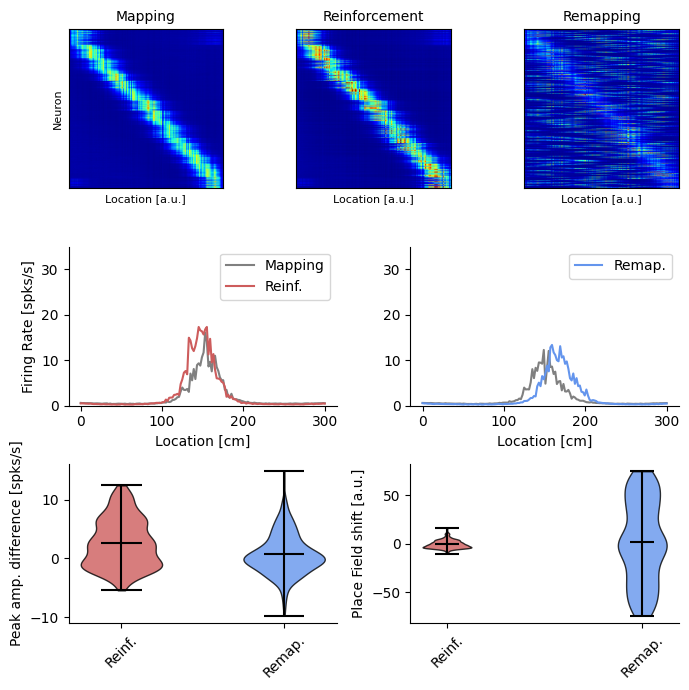

In [914]:
#fig = plt.figure(layout="constrained")
if idx == 1:
    vmax = 20
    rate_max = 35
elif idx == 2:
    vmax = 45
    rate_max = 45


fig = plt.figure(figsize=(7,7))

ax_dict = fig.subplot_mosaic(mosaic)

vmin = 0
cmap = 'jet'

neuron_id = 250

ax_dict['A'].imshow(consolidation[0]['rate_avg'].T[consolidation[0]['sorting']], vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')
ax_dict['B'].imshow(consolidation[1]['rate_avg'].T[consolidation[0]['sorting']], vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')
ax_dict['C'].imshow(remapping[1]['rate_avg'].T[remapping[0]['sorting']], vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')


for tile in place_filed_tiles:

    ax_dict[tile].set_xticks([])
    ax_dict[tile].set_yticks([])

    ax_dict[tile].set_xlabel('Location [a.u.]', fontsize=8)

ax_dict['A'].set_ylabel('Neuron', fontsize=8)

for (tile, title) in zip(place_filed_tiles, titles):
    ax_dict[tile].set_title(title, fontsize=10)

ax_dict['A'].set_ylabel('Neuron')


ax_dict['D'].plot(x_data_scaled, consolidation[0]['rate_avg'].T[consolidation[0]['sorting']][neuron_id], c='grey', label='Mapping')
ax_dict['D'].plot(x_data_scaled, consolidation[1]['rate_avg'].T[consolidation[0]['sorting']][neuron_id], c='indianred', label='Reinf.')
ax_dict['D'].set_xlabel('Location [cm]')
ax_dict['D'].set_ylabel('Firing Rate [spks/s]')
ax_dict['D'].set_ylim([0, rate_max])

ax_dict['D'].spines['top'].set_visible(False)
ax_dict['D'].spines['right'].set_visible(False)
ax_dict['D'].legend()


ax_dict['E'].plot(x_data_scaled, remapping[0]['rate_avg'].T[consolidation[0]['sorting']][neuron_id], c='grey')
ax_dict['E'].plot(x_data_scaled, remapping[1]['rate_avg'].T[consolidation[0]['sorting']][neuron_id], c='cornflowerblue', label='Remap.')
ax_dict['E'].set_xlabel('Location [cm]')
ax_dict['E'].set_ylim([0, rate_max])

ax_dict['E'].spines['top'].set_visible(False)
ax_dict['E'].spines['right'].set_visible(False)
ax_dict['E'].legend()

amp_vio_plot = ax_dict['F'].violinplot(v_data_amp.T, positions=[1, 2], showmeans=True)
ax_dict['F'].set_ylabel('Peak amp. difference [spks/s]')
ax_dict['F'].set_xticks([1, 2])
ax_dict['F'].set_xticklabels(['Reinf.', 'Remap.'], rotation=45)

amp_vio_plot_colors = ['indianred', 'cornflowerblue']

amp_vio_plot['cbars'].set_color('k')
amp_vio_plot['cmeans'].set_color('k')
amp_vio_plot['cmins'].set_color('k')
amp_vio_plot['cmaxes'].set_color('k')

for i, pc in enumerate(amp_vio_plot['bodies']):
    pc.set_facecolor(amp_vio_plot_colors[i])
    pc.set_edgecolors('k')
    pc.set_alpha(0.8)
    
ax_dict['F'].spines['top'].set_visible(False)
ax_dict['F'].spines['right'].set_visible(False)
    
shift_vio_plot_colors = ['indianred', 'cornflowerblue']

shift_vio_plot = ax_dict['G'].violinplot(v_data_place_filed_shifts.T, positions=[1, 3], showmeans=True)
ax_dict['G'].set_ylabel('Place Field shift [a.u.]')
ax_dict['G'].set_xticks([1, 3])
ax_dict['G'].set_xticklabels(['Reinf.', 'Remap.'], rotation=45)

shift_vio_plot['cbars'].set_color('k')
shift_vio_plot['cmeans'].set_color('k')
shift_vio_plot['cmins'].set_color('k')
shift_vio_plot['cmaxes'].set_color('k')

for i, pc in enumerate(shift_vio_plot['bodies']):
    pc.set_facecolor(shift_vio_plot_colors[i])
    pc.set_edgecolors('k')
    pc.set_alpha(0.8)
    
ax_dict['G'].spines['top'].set_visible(False)
ax_dict['G'].spines['right'].set_visible(False)


plt.tight_layout()

plt.savefig(f'fig2{extension}.png')

(-40.0, 40.0)

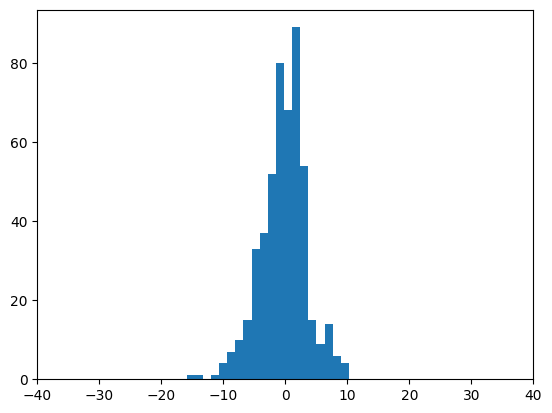

In [915]:
plt.hist(2 * place_field_reinf_shift, bins=20)
plt.xlim(-40, 40)

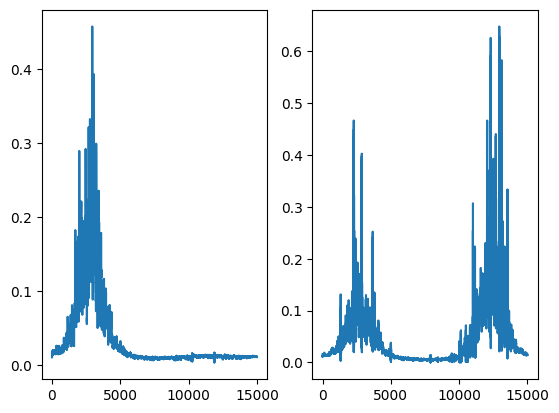

In [916]:
n = 40
fig, ax = plt.subplots(ncols=2)
ax[0].plot(remapping[0]['f'][n])
ax[1].plot(remapping[1]['f'][n])

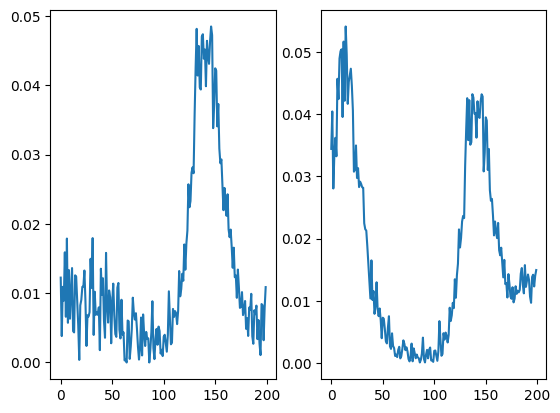

In [893]:
n = 40
fig, ax = plt.subplots(ncols=2)
ax[0].plot(remapping[0]['w_prox'][n])
ax[1].plot(remapping[1]['w_prox'][n])

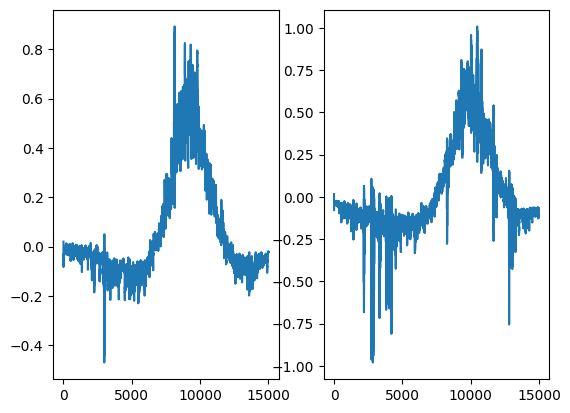

In [894]:
n = 15
fig, ax = plt.subplots(ncols=2)
ax[0].plot(remapping[0]['V'][n])
ax[1].plot(remapping[1]['V'][n])

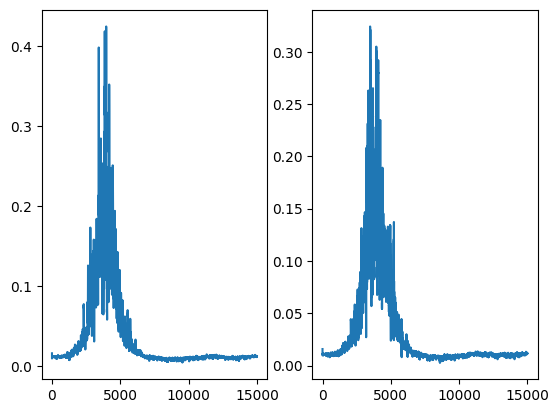

In [895]:
n = 10
fig, ax = plt.subplots(ncols=2)
ax[0].plot(consolidation[0]['f'][n])
ax[1].plot(consolidation[1]['f'][n])

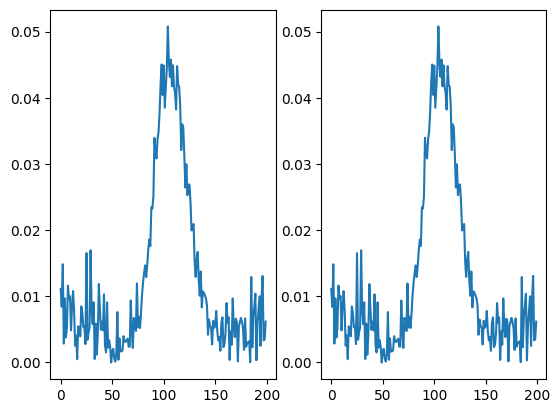

In [900]:
n = 251
fig, ax = plt.subplots(ncols=2)
ax[0].plot(consolidation[0]['w_prox'][n])
ax[1].plot(consolidation[1]['w_prox'][n])

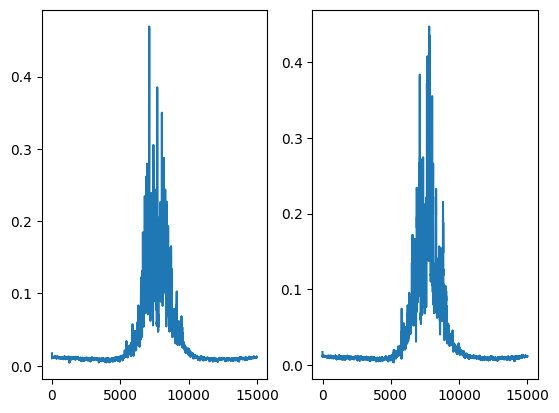

In [899]:
n = 25
fig, ax = plt.subplots(ncols=2)
ax[0].plot(consolidation[0]['f'][n])
ax[1].plot(consolidation[1]['f'][n])

In [300]:
func = lambda x, mu, sigma, fac, offset: fac * np.exp( - (x - mu)**2 / 2 / sigma**2) + offset
from scipy.optimize import curve_fit
x = np.arange(0, 200, 1)
d = remapping[0]['rate_avg'][:, idx]

In [301]:
curve_fit(func, x, d, p0=[100, 15, 20, 2])

(array([   100.65246551,   4918.35798069,  10234.10026543, -10230.3145169 ]),
 array([[ 7.70767556e+00, -5.05435683e+05, -2.10337791e+06,
          2.10337789e+06],
        [-5.05435683e+05,  5.56448942e+12,  2.31552138e+13,
         -2.31552136e+13],
        [-2.10337791e+06,  2.31552138e+13,  9.63545605e+13,
         -9.63545597e+13],
        [ 2.10337789e+06, -2.31552136e+13, -9.63545597e+13,
          9.63545588e+13]]))

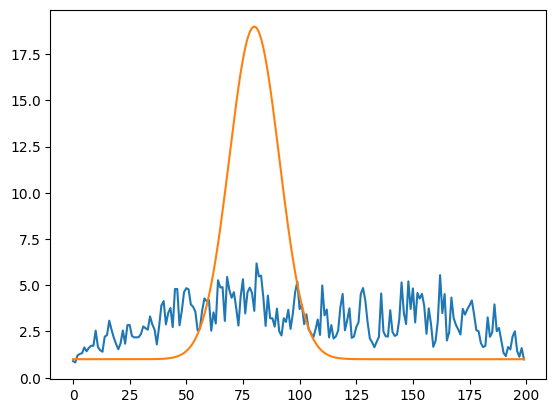

In [302]:
plt.plot(x, d)
plt.plot(x, func(x, 80, 11, 18, 1))

In [838]:
tau_short = 1000
tau_long = 2000
w_max = 1.5
w_init = 0.6
plast_kernel = lambda t: np.exp(- np.abs(t)  / tau_short ) - np.minimum((w_init / w_max)**0.5, 0.7) * 1.1 * np.exp(- np.abs(t) / tau_long)


times = np.arange(-5000, 5000, 1)

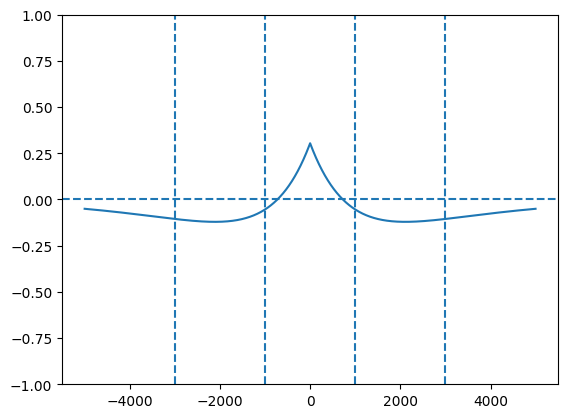

In [839]:
plt.plot(times, plast_kernel(times))
plt.ylim(-1, 1)
plt.axvline(-1000, ls='--')
plt.axvline(1000, ls='--')
plt.axhline(0, ls='--')
plt.axvline(-3000, ls='--')
plt.axvline(3000, ls='--')

In [172]:
np.maximum(w_init - 0.2, 0)

np.float64(0.39999999999999997)